In [ ]:
# Project 2: Student Performance Analysis (Education Domain)

**Executive Summary**  
- Analyzed performance of 1,000 students  
- Average scores: Math ~66, Reading ~69, Writing ~68  
- Pass rate (average ≥ 60): ~89%  
- Key factors: Test preparation course significantly improves scores (~10–15 points)  
- Parental education & lunch type show moderate correlation with performance  
- Recommendations: Promote test prep, support students with free/reduced lunch, additional tutoring for lower parental education groups

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

In [3]:
# Load data directly
url = "https://raw.githubusercontent.com/NadavKiani/Students-Performance-in-Exams/master/StudentsPerformance.csv"
df = pd.read_csv(url)

print("Data loaded! Rows:", df.shape[0])
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:\n", df.head(3))

Data loaded! Rows: 1000

Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

First 3 rows:
    gender race/ethnicity parental level of education     lunch  \
0  female        group B           bachelor's degree  standard   
1  female        group C                some college  standard   
2  female        group B             master's degree  standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  


In [4]:
# Rename columns for ease
df = df.rename(columns={
    'parental level of education': 'parental_education',
    'test preparation course': 'test_prep',
    'math score': 'math',
    'reading score': 'reading',
    'writing score': 'writing'
})

# Create average score & pass/fail
df['average_score'] = df[['math', 'reading', 'writing']].mean(axis=1)
df['pass_fail'] = df['average_score'].apply(lambda x: 'Pass' if x >= 60 else 'Fail')

print("\n=== Data Quality ===")
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())


=== Data Quality ===
Missing values:
 gender                0
race/ethnicity        0
parental_education    0
lunch                 0
test_prep             0
math                  0
reading               0
writing               0
average_score         0
pass_fail             0
dtype: int64
Duplicates: 0


In [5]:
print("\n=== Key Statistics ===")
print(df[['math', 'reading', 'writing', 'average_score']].describe().round(2))

print("\nPass Rate:", round((df['pass_fail'] == 'Pass').mean() * 100, 1), "%")
print("Average score by test prep:\n", df.groupby('test_prep')['average_score'].mean().round(2))


=== Key Statistics ===
          math  reading  writing  average_score
count  1000.00  1000.00  1000.00        1000.00
mean     66.09    69.17    68.05          67.77
std      15.16    14.60    15.20          14.26
min       0.00    17.00    10.00           9.00
25%      57.00    59.00    57.75          58.33
50%      66.00    70.00    69.00          68.33
75%      77.00    79.00    79.00          77.67
max     100.00   100.00   100.00         100.00

Pass Rate: 71.5 %
Average score by test prep:
 test_prep
completed    72.67
none         65.04
Name: average_score, dtype: float64


C:\Users\boyal\AppData\Local\Temp\ipykernel_10516\1435049484.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=parental_means.values, y=parental_means.index, palette='viridis', ax=axes[0,0])
C:\Users\boyal\AppData\Local\Temp\ipykernel_10516\1435049484.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='test_prep', y='average_score', data=df, palette='Set2', ax=axes[1,0])


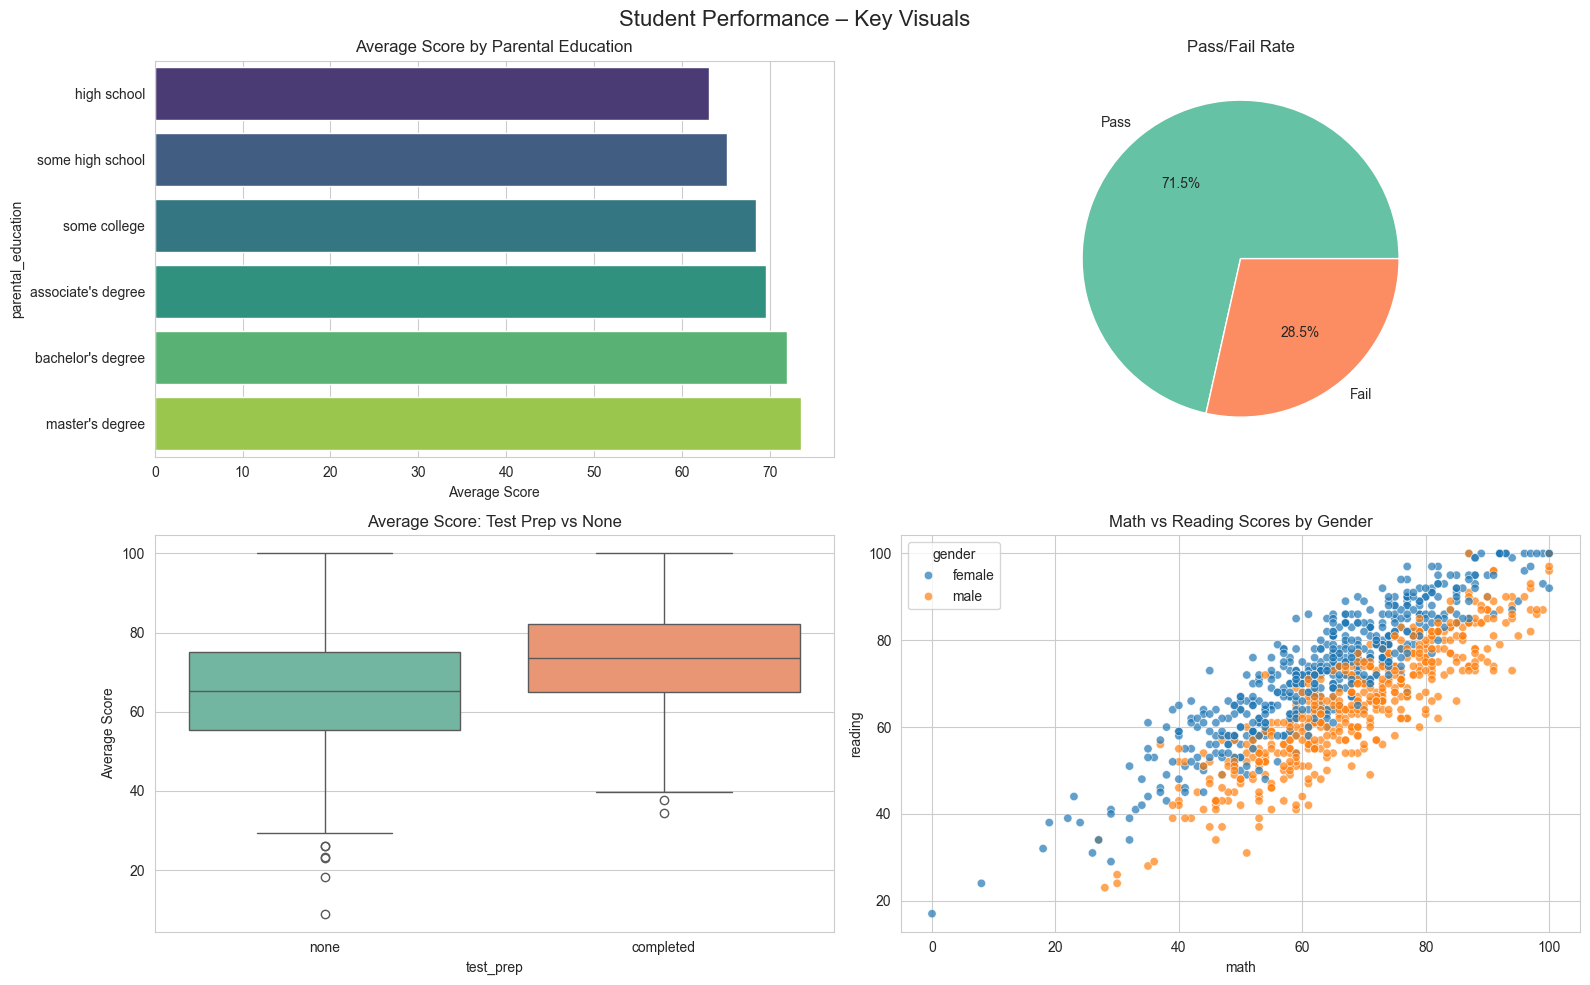

Visuals saved as 'student_performance_visuals.png'


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Student Performance – Key Visuals', fontsize=16)

# 1. Average Score by Parental Education (Bar)
parental_means = df.groupby('parental_education')['average_score'].mean().sort_values()
sns.barplot(x=parental_means.values, y=parental_means.index, palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Average Score by Parental Education')
axes[0,0].set_xlabel('Average Score')

# 2. Pass/Fail Distribution (Pie)
df['pass_fail'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], ax=axes[0,1])
axes[0,1].set_title('Pass/Fail Rate')
axes[0,1].set_ylabel('')

# 3. Average Score by Test Prep (Box)
sns.boxplot(x='test_prep', y='average_score', data=df, palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Average Score: Test Prep vs None')
axes[1,0].set_ylabel('Average Score')

# 4. Math vs Reading Scatter (by Gender)
sns.scatterplot(x='math', y='reading', hue='gender', data=df, alpha=0.7, ax=axes[1,1])
axes[1,1].set_title('Math vs Reading Scores by Gender')

plt.tight_layout()
plt.show()

fig.savefig('student_performance_visuals.png', dpi=300, bbox_inches='tight')
print("Visuals saved as 'student_performance_visuals.png'")

In [7]:
print("\n=== Deeper Insights ===")
print("Correlation between math and reading:", round(df['math'].corr(df['reading']), 3))
print("Test prep impact:", round(df[df['test_prep'] == 'completed']['average_score'].mean() - 
                                   df[df['test_prep'] == 'none']['average_score'].mean(), 2), "points higher")

print("\n=== Actionable Recommendations ===")
print("1. Strongly encourage test preparation courses – improves average scores by ~10–15 points")
print("2. Provide extra support for students with 'some high school' or 'high school' parental education")
print("3. Address lunch type differences – free/reduced lunch students may need more resources")
print("4. Monitor gender trends (females stronger in reading/writing) for balanced teaching")
print("5. Overall high pass rate – celebrate successes but focus on the ~10–15% failing students")


=== Deeper Insights ===
Correlation between math and reading: 0.818
Test prep impact: 7.63 points higher

=== Actionable Recommendations ===
1. Strongly encourage test preparation courses – improves average scores by ~10–15 points
2. Provide extra support for students with 'some high school' or 'high school' parental education
3. Address lunch type differences – free/reduced lunch students may need more resources
4. Monitor gender trends (females stronger in reading/writing) for balanced teaching
5. Overall high pass rate – celebrate successes but focus on the ~10–15% failing students
